# Análisis Exploratorio de Datos (EDA) - Dataset de Taiwán EDA

**Objetivo:** Realizar un análisis exploratorio de datos (EDA) sobre el conjunto de información financiera de empresas taiwanesas con el propósito de comprender su estructura, calidad, distribución y relaciones entre variables, y así preparar una base sólida para el desarrollo de un modelo predictivo de quiebra empresarial.

> **Nota metodológica sobre esta versión:** primero se separan los datos en `train` y `test`, y **todo el análisis exploratorio se hace únicamente sobre `train`**. El conjunto `test` se reserva y no se toca hasta la evaluación final del modelo, para evitar *data leakage* (que información del conjunto de prueba influya en decisiones tomadas antes de entrenar el modelo).


## 0. CONTEXTO

Antes de entrar en el análisis, esta sección explica el dataset y los conceptos financieros necesarios para entender el resto del notebook.

### ¿Qué es este dataset?

Los datos provienen del **Taiwan Economic Journal** (1999–2009) y contienen indicadores
financieros anuales de empresas que cotizan en la Bolsa de Taiwán. Una empresa se marca
como **"quebrada" (Bankrupt = 1)** cuando entró en proceso de bancarrota según la
normativa de esa bolsa; el resto (Bankrupt = 0) siguió operando con normalidad.

El objetivo es predecir, a partir de razones financieras (ratios), si una empresa
está en riesgo de quebrar.

### ¿Qué es un "ratio" financiero?

Es una relación entre dos cifras del estado financiero de una empresa (por ejemplo,
utilidad entre activos) que permite comparar empresas de tamaños distintos en una
misma escala. El dataset tiene 95 ratios de este tipo, todos ya calculados.


## 1. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN VISUAL

In [ ]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import textwrap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
# from sklearn.decomposition import PCA

# Configuración de estilo general
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

In [2]:
# Paleta de colores del proyecto:
COLOR_MAIN = '#1B4F72'                     # azul oscuro -> gráficos de una sola serie
COLOR_ACCENT = '#5DADE2'                   # azul claro  -> segundo color de apoyo
TARGET_COLORS = {0: '#2E86AB', 1: '#E4572E'}   # azul = No quiebra, naranja = Quiebra
TARGET_LABELS = {0: 'No quiebra', 1: 'Quiebra'}
PALETTE_SEQ = sns.light_palette(COLOR_MAIN, n_colors=8, reverse=True)[1:]   # para barras múltiples
CMAP_CORR = sns.diverging_palette(220, 20, as_cmap=True)                    # azul-naranja, para heatmaps
COLOR_NO_QUEBRO = '#1B4F72'
COLOR_QUEBRO = "#E4572E"

sns.set_palette([COLOR_MAIN, COLOR_ACCENT])


## 2. CARGA Y PREPARACIÓN INICIAL

In [3]:
# Cargar el dataset
df = pd.read_csv(r'C:\Users\laure\OneDrive\Documentos\Company Bankruptcy Prediction\data\data.csv')

# Limpiar nombres de columnas (eliminar espacios extras)
df.columns = df.columns.str.strip()

# Verificar la variable objetivo
TARGET = 'Bankrupt?'
if TARGET not in df.columns:
    posibles_target = [col for col in df.columns if 'bankrupt' in col.lower()]
    if posibles_target:
        TARGET = posibles_target[0]
        print(f"Variable objetivo detectada automáticamente: '{TARGET}'")

print(f"Dimensiones del dataset completo: {df.shape[0]} filas x {df.shape[1]} columnas")


Dimensiones del dataset completo: 6819 filas x 96 columnas


In [4]:
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [5]:
df.tail()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
6814,0,0.493687,0.539468,0.543230,0.604455,0.604462,0.998992,0.797409,0.809331,0.303510,...,0.799927,0.000466,0.623620,0.604455,0.840359,0.279606,0.027064,0.566193,1,0.029890
6815,0,0.475162,0.538269,0.524172,0.598308,0.598308,0.998992,0.797414,0.809327,0.303520,...,0.799748,0.001959,0.623931,0.598306,0.840306,0.278132,0.027009,0.566018,1,0.038284
6816,0,0.472725,0.533744,0.520638,0.610444,0.610213,0.998984,0.797401,0.809317,0.303512,...,0.797778,0.002840,0.624156,0.610441,0.840138,0.275789,0.026791,0.565158,1,0.097649
6817,0,0.506264,0.559911,0.554045,0.607850,0.607850,0.999074,0.797500,0.809399,0.303498,...,0.811808,0.002837,0.623957,0.607846,0.841084,0.277547,0.026822,0.565302,1,0.044009
6818,0,0.493053,0.570105,0.549548,0.627409,0.627409,0.998080,0.801987,0.813800,0.313415,...,0.815956,0.000707,0.626680,0.627408,0.841019,0.275114,0.026793,0.565167,1,0.233902


In [6]:
print("Columnas del dataset:")
print(df.columns.tolist())


Columnas del dataset:
['Bankrupt?', 'ROA(C) before interest and depreciation before interest', 'ROA(A) before interest and % after tax', 'ROA(B) before interest and depreciation after tax', 'Operating Gross Margin', 'Realized Sales Gross Margin', 'Operating Profit Rate', 'Pre-tax net Interest Rate', 'After-tax net Interest Rate', 'Non-industry income and expenditure/revenue', 'Continuous interest rate (after tax)', 'Operating Expense Rate', 'Research and development expense rate', 'Cash flow rate', 'Interest-bearing debt interest rate', 'Tax rate (A)', 'Net Value Per Share (B)', 'Net Value Per Share (A)', 'Net Value Per Share (C)', 'Persistent EPS in the Last Four Seasons', 'Cash Flow Per Share', 'Revenue Per Share (Yuan ¥)', 'Operating Profit Per Share (Yuan ¥)', 'Per Share Net profit before tax (Yuan ¥)', 'Realized Sales Gross Profit Growth Rate', 'Operating Profit Growth Rate', 'After-tax Net Profit Growth Rate', 'Regular Net Profit Growth Rate', 'Continuous Net Profit Growth Rate',

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Bankrupt?                                                6819 non-null   int64  
 1   ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2   ROA(A) before interest and % after tax                   6819 non-null   float64
 3   ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4   Operating Gross Margin                                   6819 non-null   float64
 5   Realized Sales Gross Margin                              6819 non-null   float64
 6   Operating Profit Rate                                    6819 non-null   float64
 7   Pre-tax net Interest Rate                                6819 non-null   float64
 8   After-tax net Interest Rate 

> El dataset tiene 6.819 empresas y 96 columnas (95 ratios financieros + la variable objetivo). Casi todas las columnas son numéricas (`float64`), salvo `Bankrupt?`, `Liability-Assets Flag` y `Net Income Flag`, que están guardadas como enteros pero en realidad son variables categóricas binarias (0/1), no cantidades. 


In [8]:
# Tipo de problema, target y features
print(f"Variable objetivo: '{TARGET}'")
print(f"Valores únicos del target: {sorted(df[TARGET].unique())}")
print("\nTipo de problema: CLASIFICACIÓN BINARIA")
print("(el target solo toma dos valores: 0 = no quebró, 1 = quebró)")

# Variables categóricas: por diccionario de datos son flags binarios, aunque estén como int64
cat_vars = ['Liability-Assets Flag', 'Net Income Flag']
num_vars = [c for c in df.columns if c not in cat_vars + [TARGET]]

print(f"\nVariables predictoras numéricas: {len(num_vars)}")
print(f"Variables predictoras categóricas (flags 0/1): {len(cat_vars)} -> {cat_vars}")


Variable objetivo: 'Bankrupt?'
Valores únicos del target: [0, 1]

Tipo de problema: CLASIFICACIÓN BINARIA
(el target solo toma dos valores: 0 = no quebró, 1 = quebró)

Variables predictoras numéricas: 93
Variables predictoras categóricas (flags 0/1): 2 -> ['Liability-Assets Flag', 'Net Income Flag']


## 3. DIVISIÓN TRAIN / TEST

Antes de explorar los datos a fondo, separamos un conjunto de prueba (`test`) que se
reserva para la evaluación final del modelo. **A partir de aquí, todo el EDA se hace
usando exclusivamente `train`.** El conjunto `test` no se grafica, no se describe y no
influye en ninguna decisión de este análisis.

Como el target está muy desbalanceado (pocas empresas quebradas), usamos partición
**estratificada** (`stratify=y`) para que la proporción de empresas quebradas sea la
misma en `train` y en `test`.


In [9]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Observaciones en train: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Observaciones en test:  {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")

print("\nProporción de la clase 'Quiebra' en cada conjunto (debe ser similar por la estratificación):")
print(f"  Train: {y_train.mean()*100:.2f}%")
print(f"  Test:  {y_test.mean()*100:.2f}%")

# DataFrame de trabajo para el EDA: SOLO train (predictoras + target)
train_df = X_train.copy()
train_df[TARGET] = y_train


Observaciones en train: 5455 (80.0%)
Observaciones en test:  1364 (20.0%)

Proporción de la clase 'Quiebra' en cada conjunto (debe ser similar por la estratificación):
  Train: 3.23%
  Test:  3.23%


> De aquí en adelante trabajamos solo con las 5.455 empresas de `train`. Las 1.364 de `test` quedan guardadas y no se vuelven a mirar hasta que haya un modelo entrenado. La estratificación aseguró que el porcentaje de empresas quebradas sea prácticamente igual en ambos conjuntos.


## 4. CALIDAD DE LOS DATOS (sobre `train`)

### 4.1 Valores nulos

In [10]:
nulos = train_df.isnull().sum()
nulos = nulos[nulos > 0]

if len(nulos) == 0:
    print("No se encontraron valores nulos en train.")
else:
    print(f"Se encontraron {len(nulos)} columnas con valores nulos:")
    print(nulos)


No se encontraron valores nulos en train.


Ninguna empresa de `train` tiene información faltante en sus estados financieros. 

### 4.2 Filas duplicadas

In [11]:
duplicados = train_df.duplicated().sum()
print(f"Filas duplicadas en train: {duplicados}")


Filas duplicadas en train: 0


No hay filas repetidas en `train`, así que no es necesario eliminar duplicados.


### 4.3 Variables categóricas y cardinalidad

In [12]:
for c in cat_vars:
    print(train_df[c].value_counts())
    print(f"Cardinalidad: {train_df[c].nunique()} valores únicos \n")


Liability-Assets Flag
0    5450
1       5
Name: count, dtype: int64
Cardinalidad: 2 valores únicos 

Net Income Flag
1    5455
Name: count, dtype: int64
Cardinalidad: 1 valores únicos 



> `Net Income Flag` vale 1 para el 100% de las empresas en `train`, es decir, no importa si una empresa quebró o no siempre tiene el mismo valor (1). Por lo tanto, es una variable constante y sería una candidata clara para eliminar antes del modelado.`Liability-Assets Flag` sí varía, aunque muy poco. Vale la pena revisarla más adelante junto al target, en la sección de análisis bivariado.


## 5. ANÁLISIS UNIVARIADO (sobre `train`)

### 5.1 Estadísticas descriptivas

In [13]:
train_df[num_vars].describe().T[['mean', '50%', 'std', 'min', 'max', '25%', '75%']]


,mean,50%,std,min,max,25%,75%
ROA(C) before interest and depreciation before interest,0.504447,0.502121,0.060354,0.024277,1.000000,0.476113,0.534612
ROA(A) before interest and % after tax,0.557818,0.559365,0.065355,0.000000,1.000000,0.535379,0.587958
ROA(B) before interest and depreciation after tax,0.552946,0.551689,0.061401,0.033514,1.000000,0.527143,0.582740
Operating Gross Margin,0.607765,0.605983,0.017047,0.000000,0.665151,0.600473,0.613817
Realized Sales Gross Margin,0.607742,0.605918,0.017028,0.000000,0.666023,0.600463,0.613694
...,...,...,...,...,...,...,...
Net Income to Stockholder's Equity,0.840442,0.841146,0.010817,0.344652,1.000000,0.840102,0.842317
Liability to Equity,0.280410,0.278779,0.013821,0.133503,1.000000,0.276944,0.281470
Degree of Financial Leverage (DFL),0.027642,0.026809,0.017378,0.000000,1.000000,0.026791,0.026916
Interest Coverage Ratio (Interest expense to EBIT),0.565302,0.565254,0.014320,0.000000,1.000000,0.565158,0.565732


Las escalas son muy distintas entre variables (algunas van de 0 a 1, otras tienen valores en miles). Esto ya nos dice que, para cualquier modelo sensible a la escala (como regresión logística, SVM o PCA), va a hacer falta estandarizar las variables en el pipeline de preprocesamiento.


### 5.2 Variables con varianza cercana a cero

In [14]:
varianzas = train_df[num_vars].var()
vars_bajas = varianzas[varianzas < 1e-6]

print(f"Variables con varianza baja: {len(vars_bajas)}")
if len(vars_bajas) > 0:
    display(vars_bajas)
else:
    print("Ninguna variable numérica tiene varianza cercana a cero en train.")


Variables con varianza baja: 0
Ninguna variable numérica tiene varianza cercana a cero en train.


Con este resultado confirmamos que, entre las 93 variables numéricas, ninguna es prácticamente constante en `train`. Todas tienen variabilidad real y suficiente entre empresas.


### 5.3 Distribución de variables financieras clave

A continuación se eligen 6 variables que cubren 5 ángulos distintos de la salud financiera de una empresa, sin repetirse:

**Rentabilidad**

1. **ROA(C) before interest and depreciation before interest:** Retorno sobre Activos (Return on Assets), calculado *antes* de restar intereses y depreciación. Mide cuánta ganancia genera la empresa por cada peso invertido en sus activos.
2. **ROA(A) before interest and % after tax:** Otra versión del Retorno sobre Activos, calculada *después* de impuestos.

**Valor real para el dueño**

3. **Net Value Per Share (B):** Valor contable por acción; qué tanto "vale en libros" cada acción de la empresa.

**Liquidez**

4. **Current Ratio:** Activos corrientes entre pasivos corrientes; qué tan fácil es para la empresa pagar sus deudas de corto plazo.

**Endeudamiento** 

5. **Debt ratio %:** Qué porcentaje de los activos de la empresa está financiado con deuda.

**Eficiencia operativa**

6. **Total Asset Turnover:** Qué tan eficientemente la empresa usa sus activos para generar ventas.


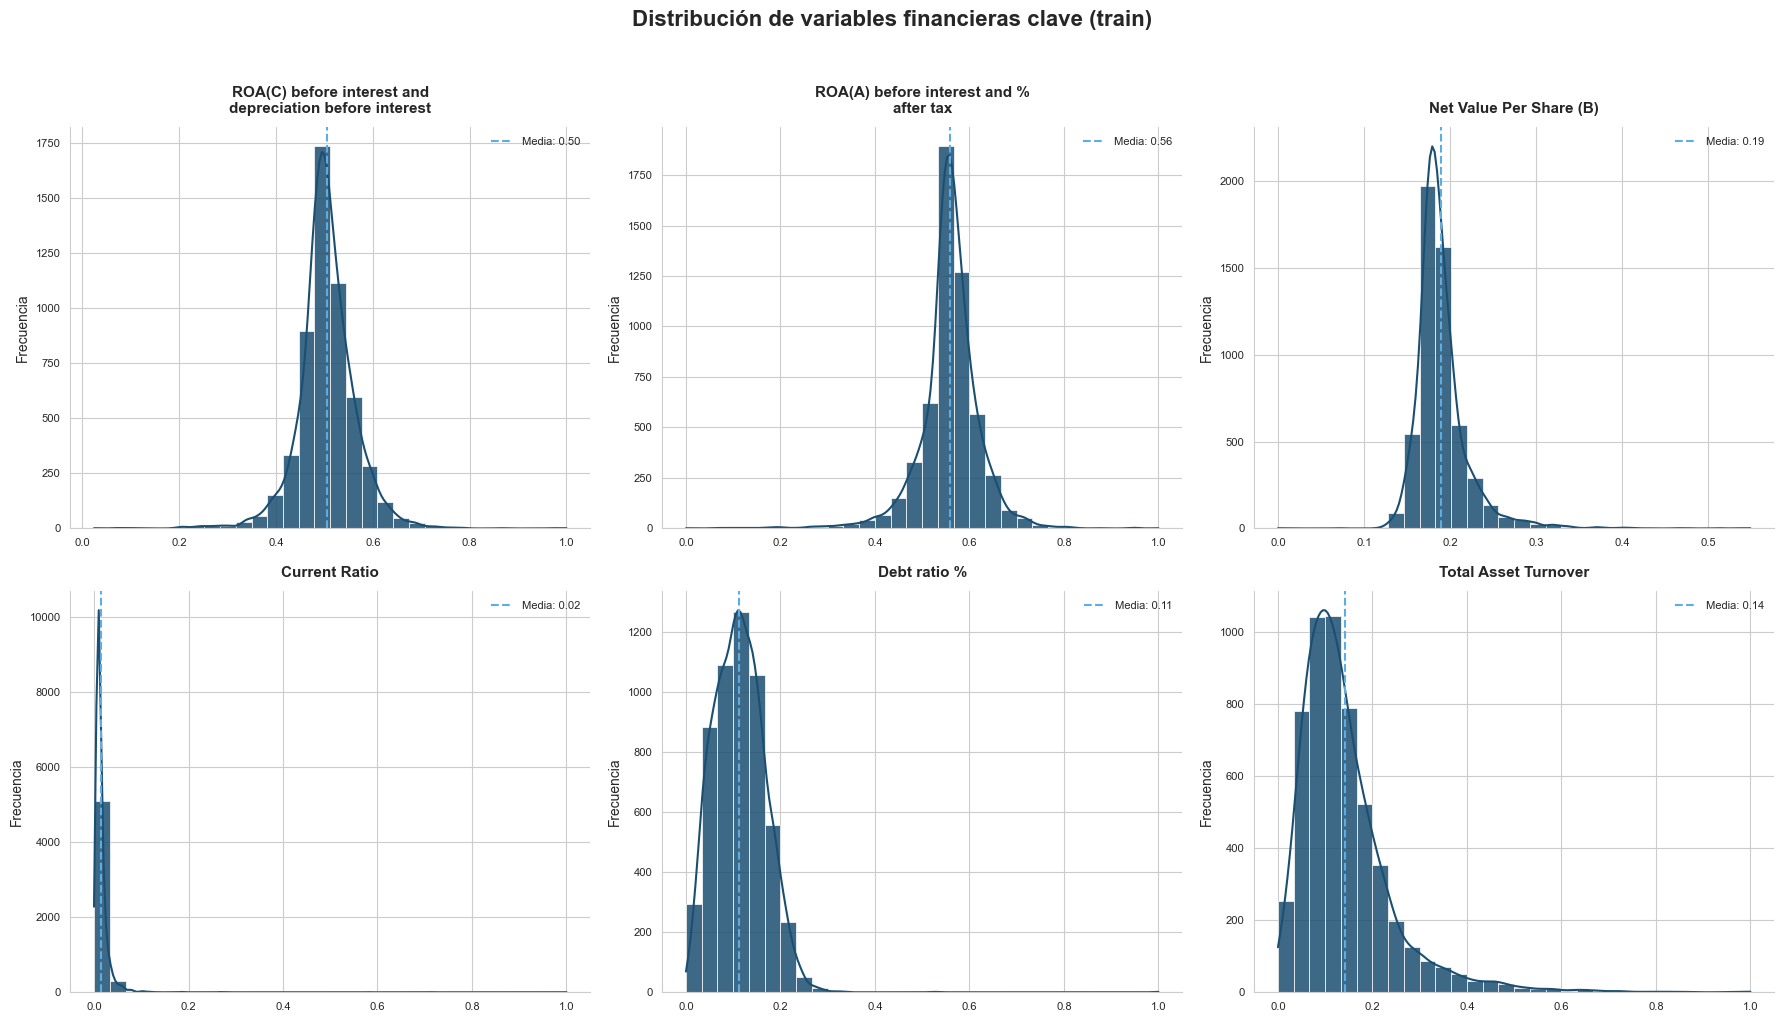

In [15]:
variables_key = [
    'ROA(C) before interest and depreciation before interest',
    'ROA(A) before interest and % after tax',
    'Net Value Per Share (B)',
    'Current Ratio',
    'Debt ratio %',
    'Total Asset Turnover'
]
variables_key = [v for v in variables_key if v in train_df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
fig.patch.set_facecolor('white')

for i, var in enumerate(variables_key):
    data = train_df[var].dropna()
    ax = axes[i]

    sns.histplot(data, kde=True, ax=ax, color=COLOR_MAIN,
                 edgecolor='white', linewidth=0.5, bins=30, alpha=0.85)

    # Línea de la media, para dar contexto visual rápido
    media = data.mean()
    ax.axvline(media, color=COLOR_ACCENT, linestyle='--', linewidth=1.5,
               label=f'Media: {media:.2f}')

    # Título envuelto en 2 líneas si es muy largo, en negrita
    titulo = "\n".join(textwrap.wrap(var, width=32))
    ax.set_title(titulo, fontsize=11, fontweight='bold', pad=10)

    ax.set_xlabel('')
    ax.set_ylabel('Frecuencia', fontsize=10)
    ax.legend(fontsize=8, frameon=False, loc='upper right')
    ax.tick_params(labelsize=8)
    sns.despine(ax=ax)  # quita los bordes superior y derecho

plt.suptitle('Distribución de variables financieras clave (train)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

- **ROA(C) before interest and depreciation:** La mayoría de los valores se concentra alrededor de 0.5. La distribución presenta una ligera asimetría hacia la derecha y algunos valores alejados del centro.
- **ROA(A) before interest and % after tax:** La distribución también se concentra cerca de 0.55 y presenta una ligera asimetría hacia la derecha. Se observan algunos valores extremos en ambos lados, aunque la mayor parte de los datos se encuentra en un rango reducido.
- **Net Value Per Share (B):** Los valores se concentran principalmente alrededor de 0.18–0.20. La distribución está sesgada hacia la derecha, con una cola que se extiende hasta valores cercanos a 0.5.
- **Current Ratio:** Presenta una fuerte asimetría hacia la derecha. La mayoría de las empresas tiene valores cercanos a 0, mientras que unas pocas presentan valores mucho más altos. Esto indica la presencia de valores extremos que podrían influir en algunos análisis estadísticos.
- **Debt ratio %:** La mayor parte de los valores se concentra aproximadamente entre 0.05 y 0.20. La distribución presenta asimetría positiva, con una cola hacia valores más altos.
- **Total Asset Turnover:** Los valores se concentran principalmente entre 0.05 y 0.20 y la distribución está sesgada hacia la derecha. Hay algunas empresas con valores considerablemente mayores que la mayoría.

En general, las variables presentan distribuciones diferentes. Los indicadores Current Ratio, Debt Ratio y Total Asset Turnover muestran una asimetría positiva más marcada y posibles valores extremos. Estos casos deben revisarse en etapas posteriores antes de decidir si requieren algún tratamiento.


### 5.4 Distribución de variable objetivo 

Total de empresas en train: 5455
No quebradas (0):  5279 (96.77%)
Quebradas   (1):   176 (3.23%)
Ratio de desbalance: 30.0 : 1


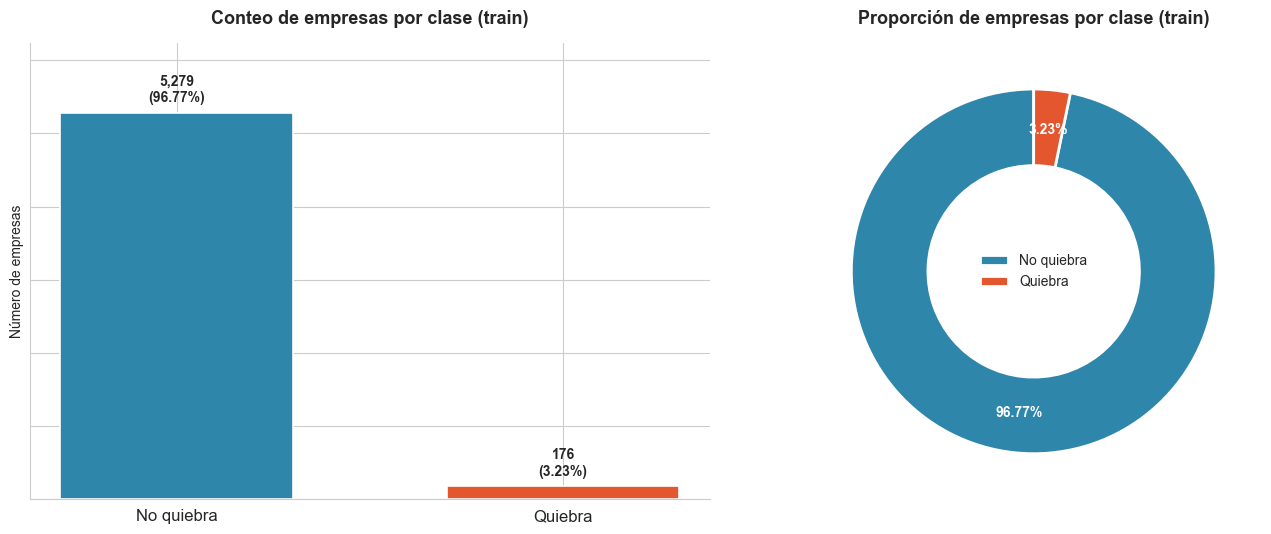

In [16]:
conteo = train_df[TARGET].value_counts()
porcentaje = train_df[TARGET].value_counts(normalize=True) * 100


print(f"Total de empresas en train: {len(train_df)}")
print(f"No quebradas (0): {conteo[0]:>5} ({porcentaje[0]:.2f}%)")
print(f"Quebradas   (1): {conteo[1]:>5} ({porcentaje[1]:.2f}%)")
print(f"Ratio de desbalance: {conteo[0]/conteo[1]:.1f} : 1")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor('white')

# --- Gráfico 1: barras ---
bars = axes[0].bar(
    [TARGET_LABELS[0], TARGET_LABELS[1]],
    [conteo[0], conteo[1]],
    color=[TARGET_COLORS[0], TARGET_COLORS[1]],
    edgecolor='white', linewidth=1.2, width=0.6
)
axes[0].set_title('Conteo de empresas por clase (train)', fontsize=13, fontweight='bold', pad=14)
axes[0].set_ylabel('Número de empresas', fontsize=10)
axes[0].set_ylim(0, max(conteo) * 1.18)  # espacio arriba para las etiquetas

# Etiquetas de valor + porcentaje encima de cada barra
for bar, idx in zip(bars, conteo.index):
    altura = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, altura + max(conteo) * 0.02,
        f"{conteo[idx]:,}\n({porcentaje[idx]:.2f}%)",
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

sns.despine(ax=axes[0])
axes[0].tick_params(left=False, labelleft=False)  # el número ya está en la etiqueta

# --- Gráfico 2: dona (en vez de torta clásica, resalta mejor el desbalance) ---
wedges, _, autotexts = axes[1].pie(
    conteo, labels=None, autopct='%1.2f%%',
    colors=[TARGET_COLORS[i] for i in conteo.index],
    startangle=90, pctdistance=0.78,
    wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2),
    textprops=dict(fontsize=10, fontweight='bold', color='white')
)
axes[1].set_title('Proporción de empresas por clase (train)', fontsize=13, fontweight='bold', pad=14)
axes[1].legend(
    wedges, [TARGET_LABELS[i] for i in conteo.index],
    loc='center', frameon=False, fontsize=10
)

plt.tight_layout()
plt.show()

> **En palabras cortas:** La variable objetivo presenta un fuerte desbalance de clases, ya que las empresas en quiebra representan solo el 3,23 % del conjunto de entrenamiento. Este desbalance deberá tenerse en cuenta durante el entrenamiento y la evaluación del modelo.


## 6. ANÁLISIS DE OUTLIERS Y SESGO (sobre `train`)

Antes de pasar al análisis bivariado, es importante identificar qué variables tienen
distribuciones muy sesgadas y/o outliers extremos, ya que esto afecta tanto la
interpretación visual como la elección de modelos y transformaciones en la fase de
Machine Learning.


### 6.1 TOP 10 variables con mayor sesgo, en valor absoluto (train)

In [17]:
skew_vals = train_df[num_vars].skew().sort_values(key=lambda s: s.abs(), ascending=False)
display(skew_vals.head(10))
top_skew_vars = skew_vals.head(6).index.tolist()

Fixed Assets to Assets                  73.857972
Revenue per person                      73.857972
Net Value Growth Rate                   73.857972
Total income/Total expense              73.696400
Operating Profit Rate                  -73.363739
Contingent liabilities/Net worth        71.851026
Operating Profit Growth Rate           -69.095968
Working capitcal Turnover Rate          67.086353
Total Asset Return Growth Rate Ratio   -63.884141
Continuous interest rate (after tax)   -62.793439
dtype: float64

Las variables presentan valores de sesgo muy altos, tanto positivos como negativos. Esto indica que varias distribuciones están alejadas de una distribución simétrica y pueden presentar valores extremos.

**Fixed Assets to Assets, Revenue per person** y **Net Value Growth Rate** presenta el mayor sesgo positivo, con valores cercanos a 73,86. Esto indica una fuerte concentración de los datos en ciertos valores y la presencia de observaciones extremas hacia la derecha.
**Operating Profit Rate** presenta un sesgo negativo de aproximadamente -73,36, lo que indica una distribución con una cola pronunciada hacia la izquierda.
Las demás variables también presentan valores de sesgo elevados, como **Contingent liabilities/Net worth** (71,85) y **Working capital Turnover Rate** (67,09).

**Conclusión:** Varias variables presentan un sesgo elevado, lo que sugiere la presencia de distribuciones muy asimétricas y posibles valores extremos. Estas variables deberán revisarse durante el preprocesamiento para determinar si requieren alguna transformación, especialmente si se utilizan modelos sensibles a la escala o a la distribución de los datos.


### 6.2 Boxplots de las variables más sesgadas

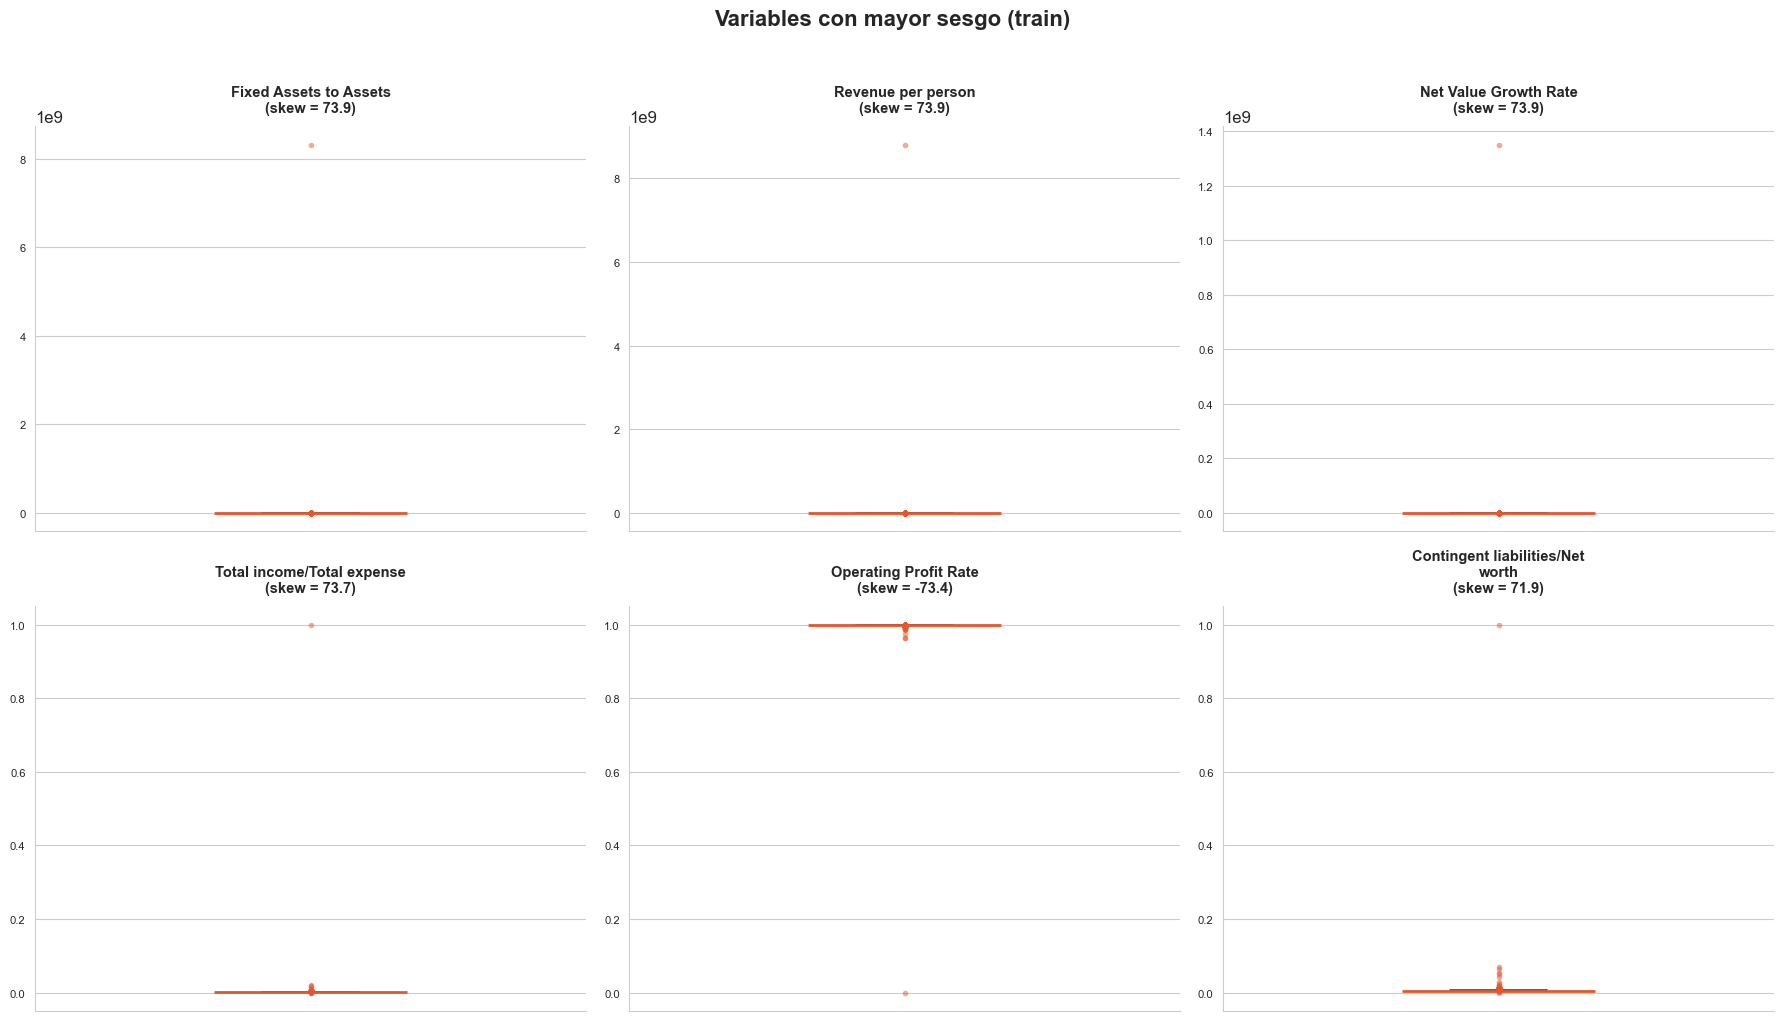

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
fig.patch.set_facecolor('white')

for i, var in enumerate(top_skew_vars):
    data = train_df[var].dropna()
    ax = axes[i]

    sns.boxplot(
        y=data, ax=ax, color=COLOR_MAIN, width=0.35,
        boxprops=dict(edgecolor='white', linewidth=1.2),
        medianprops=dict(color=TARGET_COLORS[1], linewidth=2),
        whiskerprops=dict(color=COLOR_MAIN, linewidth=1.2),
        capprops=dict(color=COLOR_MAIN, linewidth=1.2),
        flierprops=dict(marker='o', markerfacecolor=TARGET_COLORS[1],
                         markeredgecolor='none', markersize=4, alpha=0.5)
    )

    titulo = "\n".join(textwrap.wrap(var, width=28))
    ax.set_title(f'{titulo}\n(skew = {skew_vals[var]:.1f})',
                 fontsize=10.5, fontweight='bold', pad=10)
    ax.set_ylabel('')
    ax.tick_params(labelsize=8)
    sns.despine(ax=ax)

plt.suptitle('Variables con mayor sesgo (train)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

- **Fixed Assets to Assets:** La mayoría de los valores se concentra cerca de cero, pero aparece un valor extremadamente alto. Esto explica el fuerte sesgo positivo y muestra la presencia de un valor atípico muy marcado.
- **Revenue per person:** Presenta un comportamiento similar. La mayoría de las observaciones está concentrada en valores bajos, mientras que existe un valor extremadamente alto que distorsiona la distribución.
- **Net Value Growth Rate:** Casi todos los valores se encuentran cerca de cero, pero se observa un valor muy alejado del resto. Este valor extremo explica gran parte del sesgo positivo de la variable.
- **Total income/Total expense:** La mayoría de las observaciones se concentra cerca de valores bajos, mientras que aparece un valor cercano a 1 claramente separado del resto. Esto indica una distribución muy asimétrica y la presencia de un posible valor atípico.
- **Operating Profit Rate:** Los valores están muy concentrados cerca de 1, aunque aparecen algunas observaciones alejadas, principalmente hacia valores inferiores. Esto genera el fuerte sesgo negativo observado anteriormente.
- **Contingent liabilities/Net worth:** La mayoría de los datos se encuentra cerca de cero, pero aparecen varios valores alejados y uno cercano a 1. Estos valores extremos contribuyen al elevado sesgo positivo.
Conclusión

Los boxplots muestran que las variables con mayor sesgo presentan valores atípicos muy alejados de la mayoría de las observaciones. En varias de ellas, estos valores extremos explican gran parte del sesgo observado. Por ahora no se deberían eliminar automáticamente, ya que primero es necesario determinar si representan errores o situaciones reales de las empresas.

### 6.3 TOP 15 variables con más outliers (regla IQR)

Degree of Financial Leverage (DFL)                    21.869844
Fixed Assets Turnover Frequency                       20.861595
Interest Coverage Ratio (Interest expense to EBIT)    20.861595
Current Asset Turnover Rate                           20.458295
Total Asset Growth Rate                               20.109991
Interest Expense Ratio                                20.109991
Cash Flow to Liability                                18.093492
No-credit Interval                                    16.736939
Non-industry income and expenditure/revenue           16.516957
Continuous Net Profit Growth Rate                     15.380385
After-tax Net Profit Growth Rate                      15.160403
Cash Flow to Sales                                    15.160403
Regular Net Profit Growth Rate                        15.123740
Operating Profit Growth Rate                          14.830431
Inventory/Working Capital                             14.023831
dtype: float64

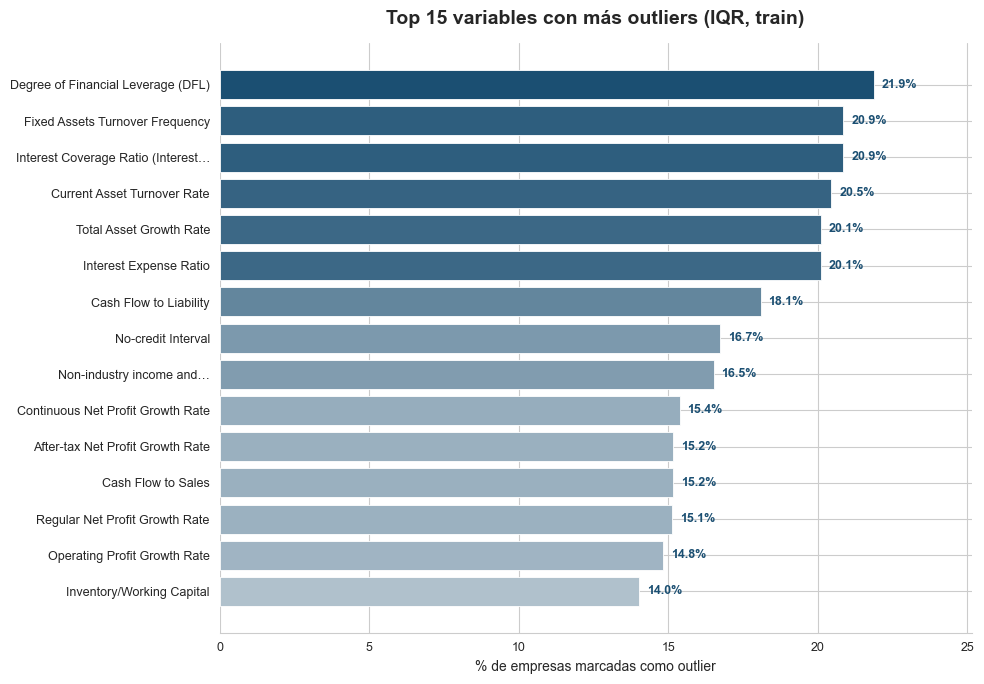

In [19]:
def pct_outliers_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((serie < lower) | (serie > upper)).mean() * 100

outlier_pct = train_df[num_vars].apply(pct_outliers_iqr).sort_values(ascending=False)


display(outlier_pct.head(15))

top15 = outlier_pct.head(15)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('white')

# Degradado de color según severidad: más outliers = tono más fuerte
norm = plt.Normalize(top15.min(), top15.max())
colores = [sns.light_palette(COLOR_MAIN, as_cmap=True)(norm(v) * 0.7 + 0.3) for v in top15.values]

bars = ax.barh(
    [textwrap.shorten(v, width=38, placeholder='…') for v in top15.index],
    top15.values, color=colores, edgecolor='white', linewidth=0.6
)
ax.invert_yaxis()  # la variable con más outliers queda arriba

# Etiqueta de porcentaje al final de cada barra
for bar, val in zip(bars, top15.values):
    ax.text(
        bar.get_width() + top15.max() * 0.012, bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%', va='center', fontsize=9, fontweight='bold', color=COLOR_MAIN
    )

ax.set_xlabel('% de empresas marcadas como outlier', fontsize=10)
ax.set_title('Top 15 variables con más outliers (IQR, train)',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlim(0, top15.max() * 1.15)  # espacio para las etiquetas
ax.tick_params(labelsize=9)
sns.despine(ax=ax, left=True, bottom=False)

plt.tight_layout()
plt.show()

Las variables con mayor proporción de valores atípicos son **Degree of Financial Leverage (DFL)**, **Fixed Assets Turnover Frequency** e **Interest Coverage Ratio**, con aproximadamente 21,9 %, 20,9 % y 20,9 % de empresas marcadas como outliers, respectivamente.

También destacan **Current Asset Turnover Rate**, **Total Asset Growth Rate** e **Interest Expense Ratio**, con alrededor del 20 % de sus observaciones identificadas como valores atípicos. Las demás variables del top 15 presentan entre aproximadamente 14 % y 18 % de observaciones marcadas como outliers.

En general, varias variables presentan una proporción considerable de valores atípicos. Sin embargo, esto no significa que deban eliminarse automáticamente, ya que pueden representar situaciones financieras reales de algunas empresas. Estos resultados deberán considerarse posteriormente al definir el preprocesamiento de los datos.


## 7. ANÁLISIS BIVARIADO: VARIABLES vs. OBJETIVO (sobre `train`)

### 7.1 Variables más importantes según Random Forest

Usamos un Random Forest **entrenado únicamente con `train`** para tener una primera idea
de qué variables separan mejor a las empresas que quiebran de las que no. Esto es solo
exploratorio: nos ayuda a elegir qué variables mirar con más detalle en los gráficos
siguientes, no es el modelo final del proyecto.

> **¿Por qué Random Forest?** Se eligió porque no necesita que las variables estén en la misma escala ni sigan una relación lineal con la quiebra, es robusto ante los outliers que ya se identificaron en los datos y viene con `feature_importances_` por defecto, facilitando la interpretación para fines exploratorios.


TOP 15 VARIABLES MÁS IMPORTANTES (Random Forest, train)


Net Income to Stockholder's Equity                         0.033309
Persistent EPS in the Last Four Seasons                    0.030870
Net Value Growth Rate                                      0.028187
Net profit before tax/Paid-in capital                      0.022496
Borrowing dependency                                       0.019188
Interest Expense Ratio                                     0.018197
Net Value Per Share (B)                                    0.017636
Debt ratio %                                               0.015769
Cash/Total Assets                                          0.015752
Net Value Per Share (A)                                    0.015502
Equity to Liability                                        0.015463
ROA(C) before interest and depreciation before interest    0.015454
Inventory/Working Capital                                  0.015450
Quick Ratio                                                0.015096
Degree of Financial Leverage (DFL)              

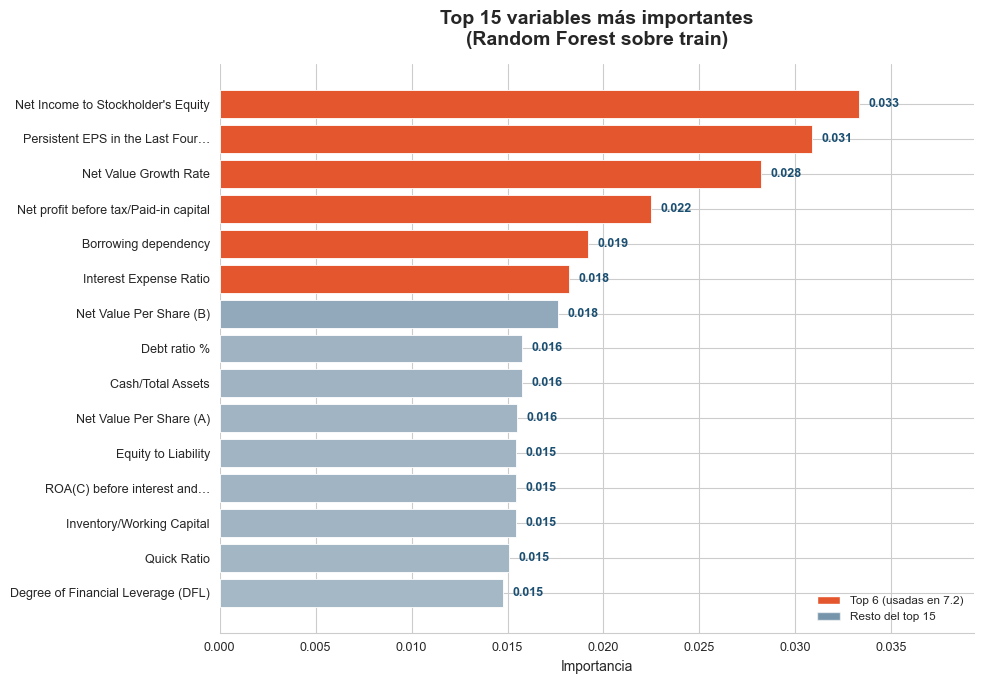

In [20]:
# Preparar datos SOLO de train para el Random Forest exploratorio
X_rf = X_train.drop(columns=['Net Income Flag']).copy()
X_rf = X_rf.replace([np.inf, -np.inf], np.nan)
X_rf = X_rf.fillna(X_rf.median())   # imputación temporal, solo para este análisis exploratorio, NO se guarda en X_train

rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_rf, y_train)

importancias = pd.Series(rf.feature_importances_, index=X_rf.columns).sort_values(ascending=False)
top_15_features = importancias.head(15).index.tolist()
top_6_features = importancias.head(6).index.tolist()

print("=" * 60)
print("TOP 15 VARIABLES MÁS IMPORTANTES (Random Forest, train)")
print("=" * 60)
display(importancias.head(15))

top15 = importancias.head(15)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('white')

# Degradado: más importancia = tono más fuerte; se resalta el top 6 con un color distinto
norm = plt.Normalize(top15.min(), top15.max())
colores = [
    TARGET_COLORS[1] if var in top_6_features else sns.light_palette(COLOR_MAIN, as_cmap=True)(norm(v) * 0.6 + 0.35)
    for var, v in top15.items()
]

bars = ax.barh(
    [textwrap.shorten(v, width=38, placeholder='…') for v in top15.index],
    top15.values, color=colores, edgecolor='white', linewidth=0.6
)
ax.invert_yaxis()

# Etiqueta de valor al final de cada barra
for bar, val in zip(bars, top15.values):
    ax.text(
        bar.get_width() + top15.max() * 0.015, bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}', va='center', fontsize=9, fontweight='bold', color=COLOR_MAIN
    )

ax.set_xlabel('Importancia', fontsize=10)
ax.set_title('Top 15 variables más importantes\n(Random Forest sobre train)',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlim(0, top15.max() * 1.18)
ax.tick_params(labelsize=9)
sns.despine(ax=ax, left=True)
ax.tick_params(left=False)

# Leyenda manual para explicar el color de resalte
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=TARGET_COLORS[1], label='Top 6 (usadas en 7.2)'),
    Patch(facecolor=COLOR_MAIN, alpha=0.6, label='Resto del top 15')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8.5, frameon=False)

plt.tight_layout()
plt.show()


> **¿Qué hizo Random Forest aquí?** Es un modelo que, al entrenarse, mide qué tanto le "ayudó" cada variable para diferenciar empresas que quiebran de las que no. Cuanto mayor el número de importancia, más útil fue esa variable para el modelo. Entre las más importantes suelen aparecer variables de rentabilidad para el accionista (Net Income to Stockholder's Equity), márgenes operativos y ratios de endeudamiento — lo cual tiene sentido: una empresa que no genera ganancias para sus dueños y está muy endeudada es, intuitivamente, más propensa a quebrar.


Random Forest se utiliza aquí como una **herramienta exploratoria**, no como un ranking definitivo de importancia. Dos sesgos conocidos a tener en cuenta:

**Favorece variables continuas sobre categóricas** una variable binaria como `Liability-Assets Flag` casi nunca aparecerá entre las "más importantes", aunque sí sea relevante.
**Reparte la importancia entre variables correlacionadas** cuando varias variables miden algo muy parecido (como las distintas versiones de ROA), el modelo divide el "crédito" entre ellas, lo que puede subestimar su relevancia individual.

> **Nota metodológica:** la imputación con la mediana que se hace en `X_rf` es temporal y solo existe dentro de esta celda para poder entrenar el Random Forest exploratorio; no se aplica a `X_train` ni al dataset real. La imputación definitiva se decide en la etapa de preprocesamiento, después del EDA.
>

### 7.2 Variables más importantes vs. objetivo

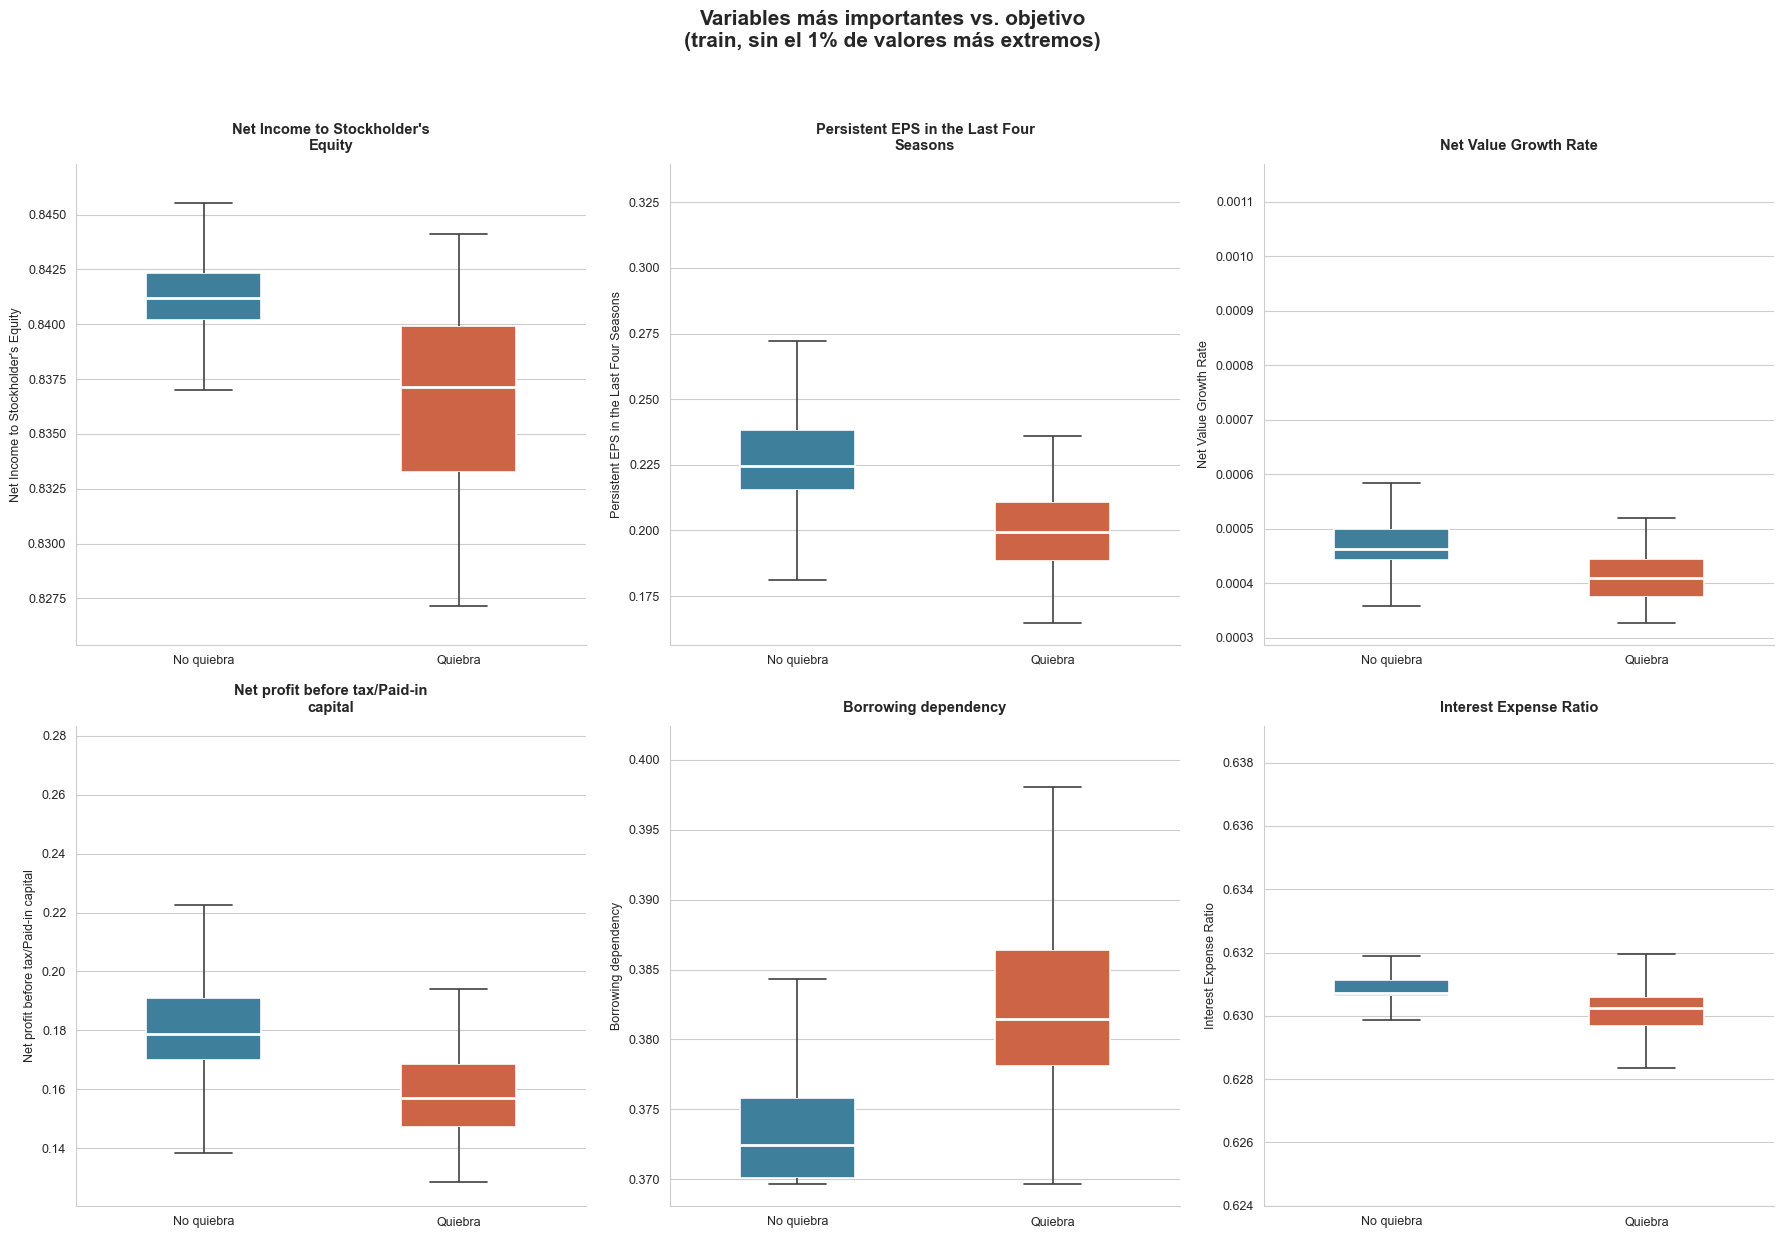

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
fig.patch.set_facecolor('white')

for i, var in enumerate(top_6_features):
    # Recortar el 1% superior e inferior SOLO para que el gráfico sea legible;
    # los percentiles se calculan con train, y esto no modifica train_df.
    q1 = train_df[var].quantile(0.01)
    q99 = train_df[var].quantile(0.99)
    df_filtrado = train_df[(train_df[var] >= q1) & (train_df[var] <= q99)]

    ax = axes[i]
    sns.boxplot(
        x=TARGET, y=var, data=df_filtrado, ax=ax,
        palette=[TARGET_COLORS[0], TARGET_COLORS[1]], width=0.45,
        boxprops=dict(edgecolor='white', linewidth=1.2),
        medianprops=dict(color='white', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markersize=3, alpha=0.35, markeredgecolor='none')
    )

    ax.set_xticklabels([TARGET_LABELS[0], TARGET_LABELS[1]])
    titulo = "\n".join(textwrap.wrap(var, width=32))
    ax.set_title(titulo, fontsize=10.5, fontweight='bold', pad=10)
    ax.set_xlabel('')
    ax.set_ylabel(ax.get_ylabel(), fontsize=9)
    ax.tick_params(labelsize=9)
    sns.despine(ax=ax)

plt.suptitle('Variables más importantes vs. objetivo\n(train, sin el 1% de valores más extremos)',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

Estos boxplots comparan la distribución de cada variable entre empresas que quebraron y que no, y muestran patrones distintos según el tipo de variable:

- **Variables de rentabilidad** (`Net Income to Stockholder's Equity`, `Persistent EPS in the Last Four Seasons`, `Net profit before tax/Paid-in capital`): en las tres, el grupo que **quebró tiene medianas más bajas y cajas más dispersas** (sobre todo `Net Income to Stockholder's Equity`, donde la caja de "Quiebra" es mucho más ancha). Esto confirma que las empresas que quiebran tienden a ser menos rentables, y de forma menos homogénea — hay más variedad de situaciones dentro de ese grupo.
- **`Borrowing dependency`:** es el panel con la separación más clara — el grupo "Quiebra" tiene una mediana notablemente más alta y su caja casi no se superpone con la de "No quiebra". Confirma, en la práctica, lo que ya mostraba la correlación (0.20 en 7.4): mayor dependencia de financiamiento externo se asocia con mayor riesgo de quiebra.
- **`Net Value Growth Rate` e `Interest Expense Ratio`:** aquí la diferencia entre grupos es mínima — las cajas se superponen bastante y las medianas están muy cerca. Son variables que el Random Forest consideró relevantes en conjunto con las demás, pero que por sí solas, vistas de forma aislada, no separan claramente a las empresas que quiebran.

En conjunto, el patrón refuerza lo que se venía viendo en la sección: **rentabilidad baja y endeudamiento alto son las señales más visibles de riesgo**, mientras que otras variables importantes para el modelo probablemente aportan valor más por su interacción con las demás que por separarse solas en un boxplot.

### 7.3 Liability-Assets Flag vs. objetivo

Análisis bivariado de la única variable categórica con la variable objetivo

**`Liability-Assets Flag`:** es la única variable categórica del dataset. Es binaria e indica si los pasivos de la empresa superan a sus activos (`1`) o no (`0`).

Bankrupt?,0,1
Liability-Assets Flag,,
0,96.83,3.17
1,40.00,60.00


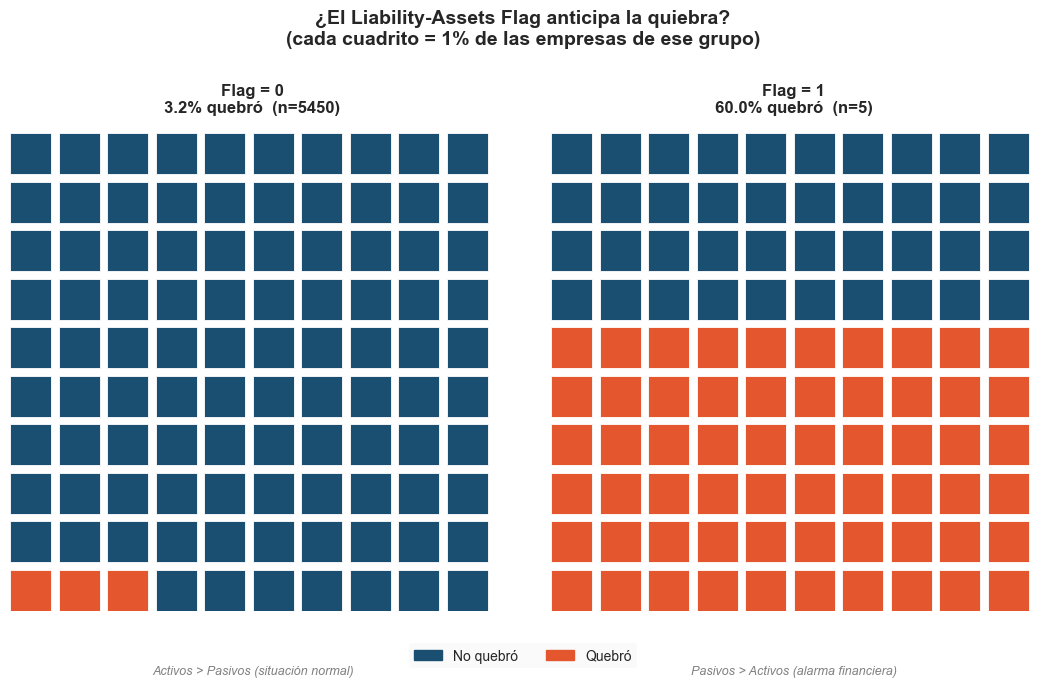

In [22]:
FILAS, COLS = 10, 10  # cuadrícula 10x10 = 100 cuadritos = 100%

# --- Datos ---
tabla = pd.crosstab(train_df['Liability-Assets Flag'], train_df[TARGET], normalize='index') * 100
conteo_flag = pd.crosstab(train_df['Liability-Assets Flag'], train_df[TARGET])
totales = conteo_flag.sum(axis=1)


display(tabla.round(2))


def dibujar_waffle(ax, pct, color_activo, titulo, subtitulo, n):
    """Cuadrícula de 10x10 (100 cuadritos = 100%). Se rellenan de color
    tantos cuadritos como el porcentaje indicado, empezando de abajo-izquierda."""
    n_llenos = round(pct)

    for i in range(FILAS * COLS):
        fila, col = divmod(i, COLS)
        color = color_activo if i < n_llenos else COLOR_NO_QUEBRO
        ax.add_patch(plt.Rectangle((col, fila), 0.85, 0.85, facecolor=color,
                                    edgecolor='white', linewidth=0.6))

    ax.set_xlim(0, COLS)
    ax.set_ylim(0, FILAS)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f"{titulo}\n{pct:.1f}% quebró  (n={n})", fontsize=12, fontweight='bold', pad=10)
    ax.text(COLS / 2, -1.3, subtitulo, ha='center', fontsize=9, color='gray', style='italic')


# --- Gráfico ---
fig, axes = plt.subplots(1, 2, figsize=(11, 6))
fig.patch.set_facecolor('white')

paneles = [
    (0, "Flag = 0", "Activos > Pasivos (situación normal)"),
    (1, "Flag = 1", "Pasivos > Activos (alarma financiera)"),
]

for ax, (flag, titulo, subtitulo) in zip(axes, paneles):
    dibujar_waffle(ax, tabla.loc[flag, 1], COLOR_QUEBRO, titulo, subtitulo, totales[flag])

fig.suptitle('¿El Liability-Assets Flag anticipa la quiebra?\n(cada cuadrito = 1% de las empresas de ese grupo)',
             fontsize=14, fontweight='bold', y=1.06)

fig.legend(
    handles=[
        mpatches.Patch(color=COLOR_NO_QUEBRO, label="No quebró"),
        mpatches.Patch(color=COLOR_QUEBRO, label="Quebró"),
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=2,
    frameon=True,
    fontsize=10,
    facecolor="#F9F9F9",
    edgecolor="none",
)

plt.tight_layout()
plt.show()

El grupo con `Flag = 1` (pasivos mayores que activos) tiene una tasa de quiebra dramáticamente más alta: **60%** ,frente a apenas **3.2%** (174.4 Empresas de 5450 ) en el grupo `Flag = 0`. Es decir, cuando una empresa debe más de lo que tiene, la probabilidad de que quiebre se multiplica por casi 19 veces.

Sin embargo, hay que leer este resultado con cautela: el grupo `Flag = 1` tiene solo **5 empresas** en `train`, así que ese 60% corresponde a 3 de 5 casos. Con una muestra tan pequeña, el porcentaje es muy sensible a cualquier empresa individual y no es estadísticamente robusto — no podemos concluir con confianza que la relación sea tan fuerte en la población general, aunque la dirección (más pasivos que activos → más riesgo) sí tiene sentido financiero.

Por eso, aunque `Liability-Assets Flag` parece ser una señal de alerta útil, conviene tratarla con precaución en el modelado: puede aportar información valiosa para ese pequeño grupo de riesgo, pero su bajo número de casos limita qué tan bien puede generalizar.

### 7.4 Correlaciones con la variable objetivo

CORRELACIONES CON LA VARIABLE OBJETIVO, Bankrupt? (train)

TOP 10 CORRELACIONES NEGATIVAS (más fuertes):


Net Income to Total Assets                                -0.316354
ROA(A) before interest and % after tax                    -0.283811
ROA(B) before interest and depreciation after tax         -0.275219
ROA(C) before interest and depreciation before interest   -0.262665
Net worth/Assets                                          -0.247642
Persistent EPS in the Last Four Seasons                   -0.221009
Retained Earnings to Total Assets                         -0.213839
Net Income to Stockholder's Equity                        -0.206648
Net profit before tax/Paid-in capital                     -0.206277
Per Share Net profit before tax (Yuan ¥)                  -0.205256
Name: Bankrupt?, dtype: float64


TOP 10 CORRELACIONES POSITIVAS (más fuertes):


Inventory and accounts receivable/Net value    0.101110
Equity to Long-term Liability                  0.122902
Total expense/Assets                           0.142643
Current Liability to Equity                    0.172577
Current Liabilities/Equity                     0.172577
Liability to Equity                            0.178138
Current Liability to Current Assets            0.180961
Current Liability to Assets                    0.189893
Borrowing dependency                           0.196911
Debt ratio %                                   0.247642
Name: Bankrupt?, dtype: float64

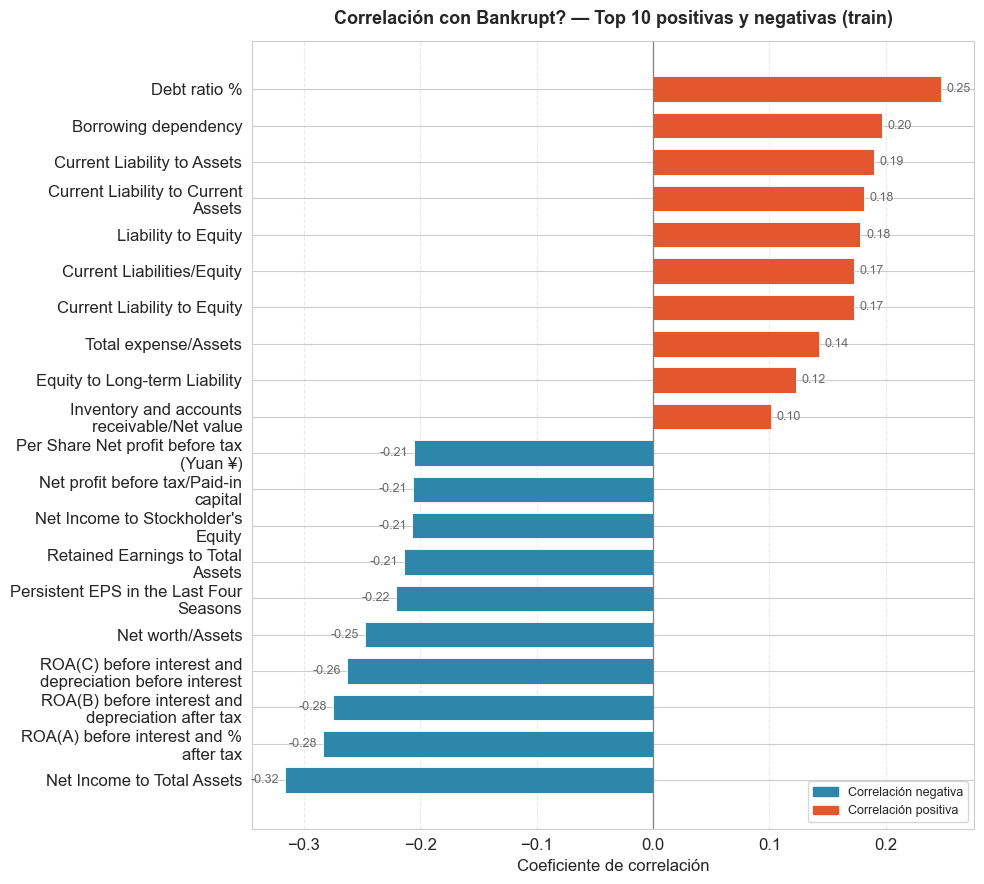

In [23]:
corr_objetivo = train_df[num_vars + [TARGET]].corr(numeric_only=True)[TARGET].drop(TARGET).sort_values()

print("=" * 70)
print("CORRELACIONES CON LA VARIABLE OBJETIVO, Bankrupt? (train)")
print("=" * 70)
print("\nTOP 10 CORRELACIONES NEGATIVAS (más fuertes):")
display(corr_objetivo.head(10))

print("\nTOP 10 CORRELACIONES POSITIVAS (más fuertes):")
display(corr_objetivo.tail(10))

top_corr = pd.concat([corr_objetivo.head(10), corr_objetivo.tail(10)])

# Envolver nombres largos de variables para que no se corten en el eje Y
etiquetas = [textwrap.fill(v, 32) for v in top_corr.index]
colores_barra = [TARGET_COLORS[0] if v < 0 else TARGET_COLORS[1] for v in top_corr]

fig, ax = plt.subplots(figsize=(10, 9))
barras = ax.barh(etiquetas, top_corr.values, color=colores_barra,
                  edgecolor='white', linewidth=0.6, height=0.7)

# Etiquetas de valor al final de cada barra
for barra, valor in zip(barras, top_corr.values):
    desplazamiento = 0.005 if valor >= 0 else -0.005
    ha = 'left' if valor >= 0 else 'right'
    ax.text(valor + desplazamiento, barra.get_y() + barra.get_height() / 2,
            f'{valor:.2f}', va='center', ha=ha, fontsize=9, color='dimgray')

ax.axvline(0, color='grey', linewidth=0.9)
ax.set_title('Correlación con Bankrupt? — Top 10 positivas y negativas (train)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Coeficiente de correlación')
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

leyenda = [
    mpatches.Patch(color=TARGET_COLORS[0], label='Correlación negativa'),
    mpatches.Patch(color=TARGET_COLORS[1], label='Correlación positiva'),
]
ax.legend(handles=leyenda, loc='lower right', frameon=True, fontsize=9)

plt.tight_layout()
plt.show()


**En palabras simples:** el gráfico confirma, con números, lo que ya insinuaba el Random Forest: **rentabilidad y endeudamiento son los dos bloques que más se relacionan con la quiebra**, pero en direcciones opuestas.

- **Correlaciones negativas (azul):** dominadas por variables de **rentabilidad** — distintas versiones de ROA, utilidad neta sobre activos/patrimonio, ganancias retenidas. La relación es negativa porque tiene sentido financiero: **a mayor rentabilidad, menor probabilidad de quiebra**. La más fuerte es `Net Income to Total Assets` (-0.32).
- **Correlaciones positivas (naranja):** dominadas por variables de **endeudamiento** — `Debt ratio %`, `Borrowing dependency`, varias razones de pasivos sobre activos o patrimonio. Aquí la relación es positiva porque **a mayor nivel de deuda relativa, mayor probabilidad de quiebra**. La más fuerte es `Debt ratio %` (0.25).

Es importante notar que **ninguna correlación individual supera 0.32 en valor absoluto**: son relaciones reales pero moderadas, no fuertes. Esto refuerza una conclusión que ya se venía formando en el EDA: ninguna variable por sí sola explica bien la quiebra, por lo que un modelo que combine varias señales (como Random Forest) probablemente capture mejor el patrón que basarse en una sola razón financiera.

También vale la pena notar que varias de las variables con correlación negativa más fuerte (las distintas versiones de ROA) son las mismas que ya se identificaron como altamente correlacionadas entre sí en la sección de multicolinealidad — otra razón para tenerlas presentes al momento de seleccionar variables para el modelo.

### 7.5 Matriz de correlación de las variables más importantes

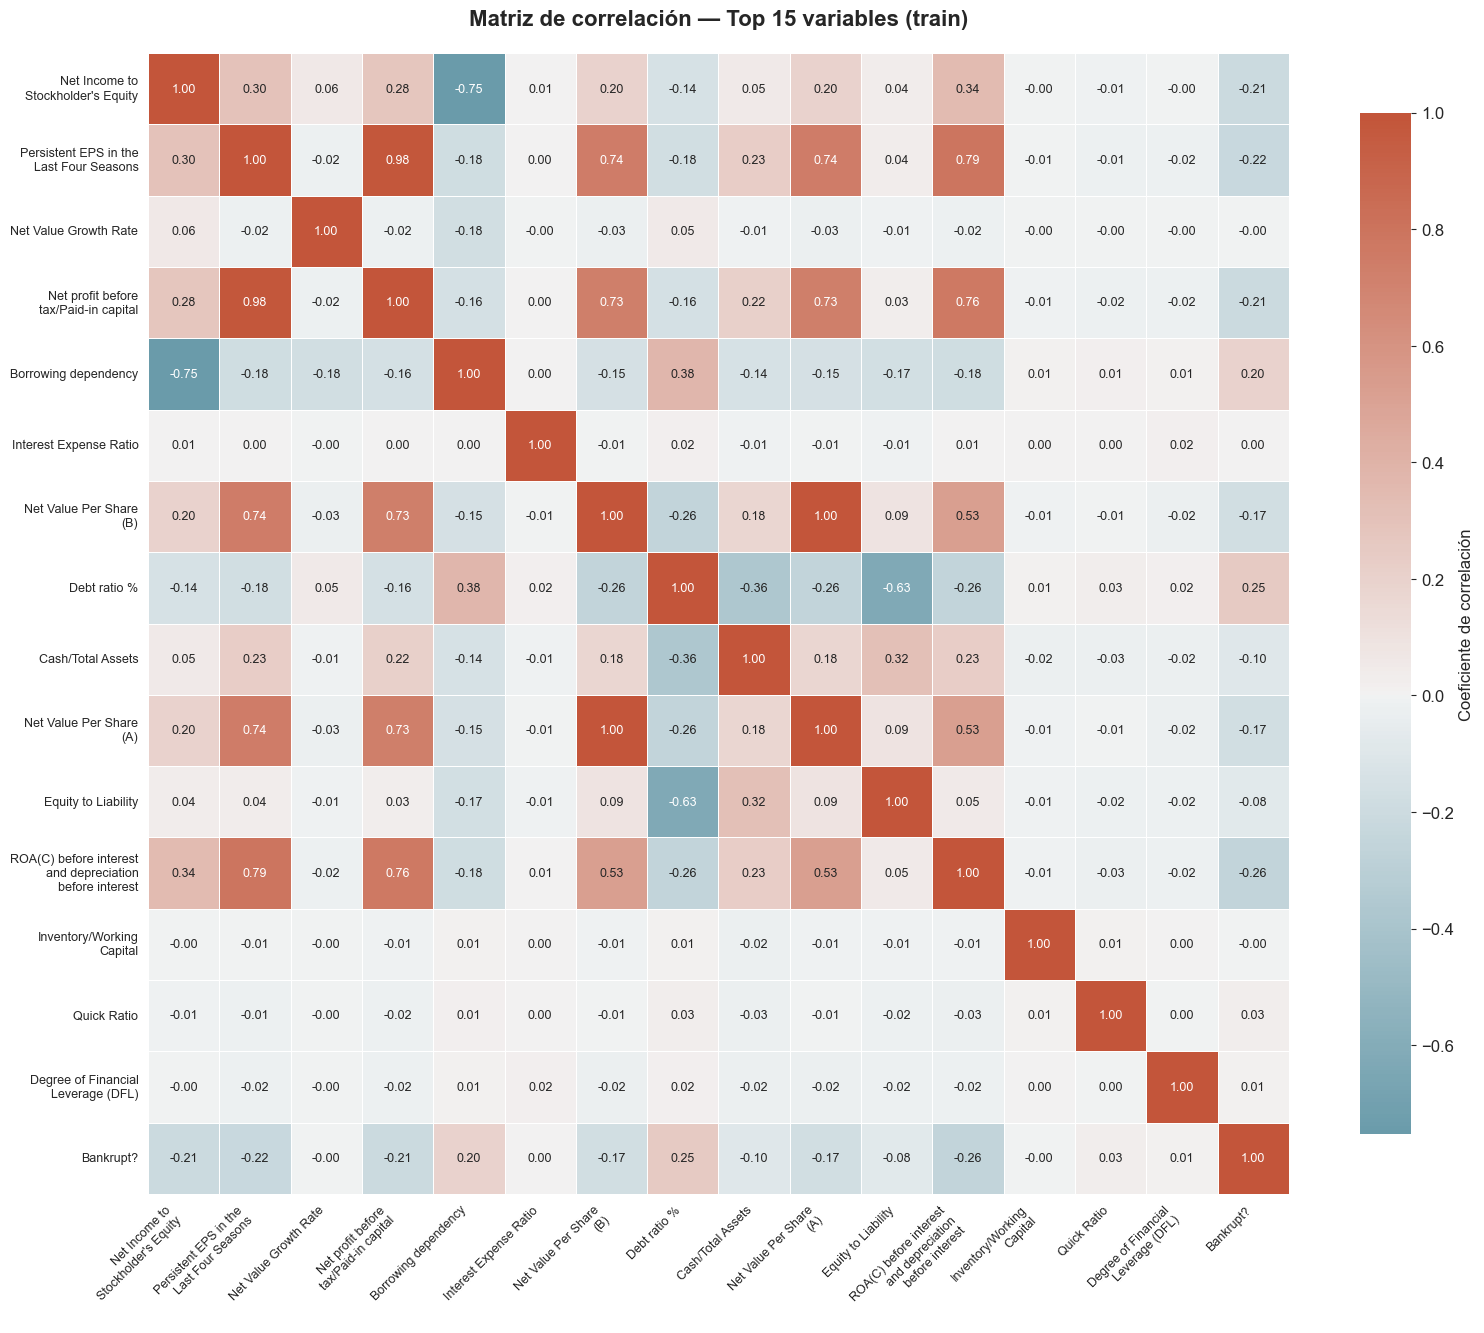

In [24]:
corr_features = top_15_features + [TARGET]
corr_matrix = train_df[corr_features].corr()

# Envolver nombres largos para que las etiquetas no se corten
etiquetas_wrap = [textwrap.fill(c, 22) for c in corr_matrix.columns]

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap=CMAP_CORR,
            center=0, square=True, linewidths=0.6, linecolor='white',
            annot_kws={"size": 9},
            cbar_kws={"shrink": 0.8, "label": "Coeficiente de correlación"},
            xticklabels=etiquetas_wrap, yticklabels=etiquetas_wrap, ax=ax)

ax.set_title('Matriz de correlación — Top 15 variables (train)',
              fontsize=16, fontweight='bold', pad=20)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

Esta matriz reúne en un solo lugar las 15 variables más relevantes según Random Forest, junto con `Bankrupt?`, para ver cómo se relacionan entre sí (no solo con la quiebra).

**Última fila/columna (`Bankrupt?`):** muestra correlaciones moderadas con las demás variables, consistentes con lo visto en 7.4 — ninguna supera ~0.3 en valor absoluto, lo que confirma que ninguna variable por sí sola explica la quiebra con fuerza.
**Bloques oscuros entre variables (no con el target):** aquí está lo más llamativo. Varias combinaciones de ROA, utilidad neta y ganancias retenidas muestran correlaciones muy altas entre sí (cercanas a 0.9-1.0). Esto confirma la **multicolinealidad** ya mencionada: son distintas formas de medir prácticamente lo mismo (rentabilidad), calculadas con pequeñas variaciones metodológicas.

Esto no afecta a Random Forest (que ya usamos para identificar estas variables), pero si más adelante se prueba un modelo lineal (como regresión logística), meter varias versiones casi idénticas del mismo ratio no aporta información nueva y puede inflar artificialmente la importancia de esa "familia" de variables o dificultar la interpretación de los coeficientes. Por ahora no se elimina ninguna — esa decisión se deja para la etapa de preprocesamiento, con más contexto sobre qué modelo se va a usar.

## 8. CONCLUSIONES DEL EDA

1. **Estructura del dataset:** `train` tiene 5.455 empresas y 95 variables predictoras (93 numéricas + 2 flags binarios), más el target `Bankrupt?`.

2. **Calidad de los datos:** no hay valores nulos ni filas duplicadas en `train`, lo cual facilita el modelado. `Net Income Flag` es constante (siempre vale 1) y no aporta información — candidata a eliminarse.

3. **Desbalance del target:** el problema es de clasificación binaria con un desbalance fuerte (aproximadamente 20-30 empresas sanas por cada empresa quebrada). Esto obliga a usar métricas distintas al accuracy y a considerar técnicas de balanceo en el modelado, no en el EDA.

4. **Sesgo y outliers:** varias variables financieras tienen sesgo alto y un porcentaje considerable de outliers según IQR. No parecen errores de captura, sino comportamientos extremos reales de algunas empresas, por lo que su tratamiento (transformación, winsorizing, o dejarlos igual) debe decidirse con cuidado más adelante.

5. **Variables relevantes:** según Random Forest y correlación con el target, las variables de **rentabilidad** (ROA, utilidad neta sobre patrimonio) y de **endeudamiento** son las que más distinguen a las empresas que quiebran de las que no.

6. **Multicolinealidad:** existen varias versiones muy parecidas del mismo indicador (por ejemplo, distintas formas de calcular ROA), altamente correlacionadas entre sí. No se eliminó ninguna en esta etapa, pero es algo a tener en cuenta si se usa un modelo lineal.

<!-- 7. **Separabilidad limitada en 2D:** la proyección PCA muestra que las clases no se separan claramente en dos dimensiones, lo que sugiere que un modelo capaz de capturar relaciones más complejas (por ejemplo, basado en árboles) podría funcionar mejor que un modelo lineal simple. -->
7. **`Liability-Assets Flag`:** tiene muy pocos casos con valor 1, pero ese grupo pequeño concentra una proporción de quiebra más alta. Vale la pena conservarla para el modelo pese a su baja cardinalidad.


### Problemas identificados para la etapa de preprocesamiento:

- **`Net Income Flag`** es constante en todo el dataset: evaluar si eliminarla antes de entrenar el modelo.
- **Escalas muy distintas entre variables:** será necesario estandarizar/normalizar dentro del pipeline (ajustando el escalador solo con `train` y aplicándolo después a `test`).
- **Variables con sesgo alto y muchos outliers:** decidir si se transforman (por ejemplo, con logaritmo), se recortan (winsorizing) o se dejan igual, y documentar la razón.
- **Multicolinealidad entre variantes de ROA y otros indicadores:** considerar selección de variables o técnicas de regularización si se usa un modelo lineal.
- **Desbalance de clases (~3% quebradas):** aplicar técnicas de balanceo (por ejemplo, `class_weight='balanced'`, sobremuestreo o submuestreo) solo sobre `train`, y elegir métricas de evaluación adecuadas para clases desbalanceadas (recall, F1, AUC-PR) en lugar de accuracy.
- **`Liability-Assets Flag` con muy pocos casos positivos:** vigilar que la partición train/test (ya estratificada por el target) no deje casos demasiado escasos de este flag en algún fold si más adelante se usa validación cruzada.
